# Melbourne Housing Price Prediction using Linear Regression

## Introduction
Housing prices in Melbourne are influenced by a range of factors including location, property size, and number of bedrooms. This project aims to build a predictive model that estimates the sold price of a property based on these characteristics, using a dataset of 150 property sales across the suburbs of Hawthorn, Ringwood, and Burwood.
The goal is to understand which features most strongly influence sold price, and to build a model that can reasonably predict the price of a property given its attributes. This involved cleaning and preparing the dataset, exploring relationships between variables, and training a Linear Regression model evaluated using 5-fold cross validation to ensure reliable performance estimates.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

## Data Preprocessing

In [2]:
df = pd.read_csv('melbourne_housing.csv')

df.head()

,Suburb,Sold Price (AUD),Property Type,Bedrooms,Bathrooms,Car Spaces,Land Size (m2),Floor Area (m2),Sale Date,Travel Time to CBD (min),Has Garden
0,Hawthorn,928000,Unit,2,1,1,NaN,NaN,09/05/2026,25,1
1,Hawthorn,712500,Unit,2,1,1,NaN,90.0,09/05/2026,20,0
2,Hawthorn,687000,Unit,2,2,1,NaN,NaN,09/05/2026,20,0
3,Hawthorn,390000,Unit,1,1,1,NaN,NaN,08/05/2026,21,0
4,Hawthorn,735000,Unit,2,2,1,NaN,93.0,07/05/2026,23,0


In [3]:
print('Shape:\n ', df.shape)

print('\n Info: ')
df.info()

print('\n Missing Values:\n ', df.isnull().sum())

Shape:
  (150, 11)

 Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Suburb                    150 non-null    object 
 1   Sold Price (AUD)          150 non-null    int64  
 2   Property Type             150 non-null    object 
 3   Bedrooms                  150 non-null    int64  
 4   Bathrooms                 150 non-null    int64  
 5   Car Spaces                150 non-null    int64  
 6   Land Size (m2)            55 non-null     float64
 7   Floor Area (m2)           11 non-null     float64
 8   Sale Date                 150 non-null    object 
 9   Travel Time to CBD (min)  150 non-null    int64  
 10  Has Garden                150 non-null    int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 13.0+ KB

 Missing Values:
  Suburb                        0
Sold Price (AUD)              0
Prope

In [4]:
# Too many missing values
df = df.drop(columns=['Floor Area (m2)'])

# Fill missing values with 0
df['Land Size (m2)'] = df['Land Size (m2)'].fillna(0)

print('Missing Values after fix:\n ', df.isnull().sum())

Missing Values after fix:
  Suburb                      0
Sold Price (AUD)            0
Property Type               0
Bedrooms                    0
Bathrooms                   0
Car Spaces                  0
Land Size (m2)              0
Sale Date                   0
Travel Time to CBD (min)    0
Has Garden                  0
dtype: int64


In [5]:
# Convert Sale Date to datetime format
df['Sale Date'] = pd.to_datetime(df['Sale Date'], format = '%d/%m/%Y')

df['Sale Year'] = df['Sale Date'].dt.year
df['Sale Month'] = df['Sale Date'].dt.month

df = df.drop(columns = ['Sale Date']) #no longer needed

print('Updated:\n ', df.head())

Updated:
       Suburb  Sold Price (AUD) Property Type  Bedrooms  Bathrooms  Car Spaces  \
0  Hawthorn            928000          Unit         2          1           1   
1  Hawthorn            712500          Unit         2          1           1   
2  Hawthorn            687000          Unit         2          2           1   
3  Hawthorn            390000          Unit         1          1           1   
4  Hawthorn            735000          Unit         2          2           1   

   Land Size (m2)  Travel Time to CBD (min)  Has Garden  Sale Year  Sale Month  
0             0.0                        25           1       2026           5  
1             0.0                        20           0       2026           5  
2             0.0                        20           0       2026           5  
3             0.0                        21           0       2026           5  
4             0.0                        23           0       2026           5  


In [6]:
df_viz = df.copy() # Save this copy for visualisation later

In [7]:
# One-hot encode
df = pd.get_dummies(df, columns = ['Suburb', 'Property Type'])

df.head()

,Sold Price (AUD),Bedrooms,Bathrooms,Car Spaces,Land Size (m2),Travel Time to CBD (min),Has Garden,Sale Year,Sale Month,Suburb_Burwood,Suburb_Hawthorn,Suburb_Ringwood,Property Type_House,Property Type_Unit
0,928000,2,1,1,0.0,25,1,2026,5,False,True,False,False,True
1,712500,2,1,1,0.0,20,0,2026,5,False,True,False,False,True
2,687000,2,2,1,0.0,20,0,2026,5,False,True,False,False,True
3,390000,1,1,1,0.0,21,0,2026,5,False,True,False,False,True
4,735000,2,2,1,0.0,23,0,2026,5,False,True,False,False,True


In [8]:
# Scaling
scale_cols = ['Bedrooms', 'Bathrooms', 'Car Spaces', 
              'Land Size (m2)', 'Travel Time to CBD (min)',
              'Sale Year', 'Sale Month']

scaler = StandardScaler()

df[scale_cols] = scaler.fit_transform(df[scale_cols])

df.head()

,Sold Price (AUD),Bedrooms,Bathrooms,Car Spaces,Land Size (m2),Travel Time to CBD (min),Has Garden,Sale Year,Sale Month,Suburb_Burwood,Suburb_Hawthorn,Suburb_Ringwood,Property Type_House,Property Type_Unit
0,928000,-0.435319,-0.802706,-0.587684,-0.679444,-0.927965,1,0.562978,0.144841,False,True,False,False,True
1,712500,-0.435319,-0.802706,-0.587684,-0.679444,-1.741969,0,0.562978,0.144841,False,True,False,False,True
2,687000,-0.435319,0.942306,-0.587684,-0.679444,-1.741969,0,0.562978,0.144841,False,True,False,False,True
3,390000,-1.329810,-0.802706,-0.587684,-0.679444,-1.579168,0,0.562978,0.144841,False,True,False,False,True
4,735000,-0.435319,0.942306,-0.587684,-0.679444,-1.253566,0,0.562978,0.144841,False,True,False,False,True


In [9]:
# Convert True/False to 1/0
df = df.astype({
    'Suburb_Burwood' : int,
    'Suburb_Hawthorn' : int,
    'Suburb_Ringwood' : int,
    'Property Type_House' : int,
    'Property Type_Unit' : int})

df.head()

,Sold Price (AUD),Bedrooms,Bathrooms,Car Spaces,Land Size (m2),Travel Time to CBD (min),Has Garden,Sale Year,Sale Month,Suburb_Burwood,Suburb_Hawthorn,Suburb_Ringwood,Property Type_House,Property Type_Unit
0,928000,-0.435319,-0.802706,-0.587684,-0.679444,-0.927965,1,0.562978,0.144841,0,1,0,0,1
1,712500,-0.435319,-0.802706,-0.587684,-0.679444,-1.741969,0,0.562978,0.144841,0,1,0,0,1
2,687000,-0.435319,0.942306,-0.587684,-0.679444,-1.741969,0,0.562978,0.144841,0,1,0,0,1
3,390000,-1.329810,-0.802706,-0.587684,-0.679444,-1.579168,0,0.562978,0.144841,0,1,0,0,1
4,735000,-0.435319,0.942306,-0.587684,-0.679444,-1.253566,0,0.562978,0.144841,0,1,0,0,1


In [10]:
# save a cleaned copy
df.to_csv('cleaned_melbourne_housing.csv', index = False)

## Data Analysis

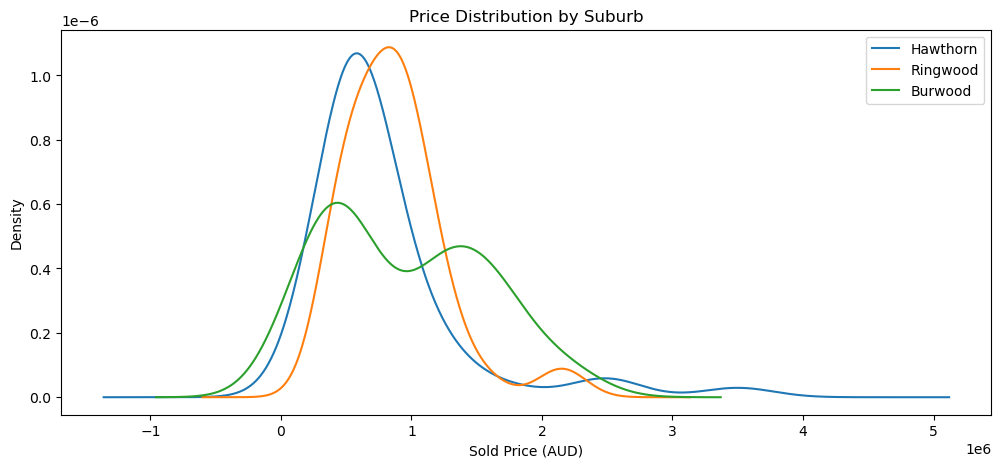

In [11]:
# KDE
plt.figure(figsize=(12,5))
for suburb in df_viz['Suburb'].unique():
    subset = df_viz[df_viz['Suburb']==suburb]['Sold Price (AUD)']
    subset.plot(kind='kde', label=suburb)

plt.title('Price Distribution by Suburb')
plt.xlabel('Sold Price (AUD)')
plt.legend()
plt.show()

### Observation:

Hawthorn - The long tail at the end shows that the prices vary a lot, there are some very expensive properties pulling the range out.  
Ringwood - Most properties sell in a similar price range, quite consistent.  
Burwood - There are two obvious groups of properties, the cheaper ones and the expensive ones.

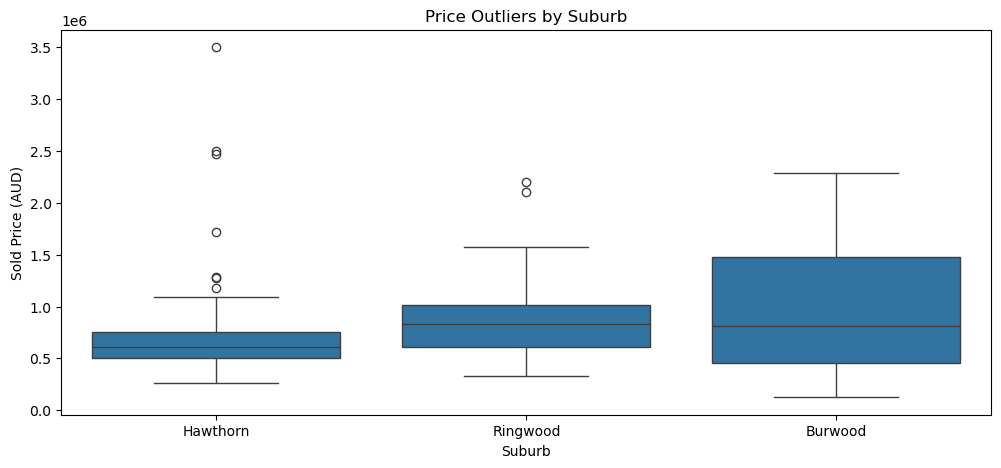

In [12]:
# Box plot
plt.figure(figsize=(12,5))
sns.boxplot(x=df_viz['Suburb'], y=df_viz['Sold Price (AUD)'])
plt.title('Price Outliers by Suburb')
plt.show()

### Observation:

Hawthorn - Tight box so it has consistent prices but the dots show that it has a lot of outliers (very expensive properties).  
Ringwood - Most consistent, tight box, not many outliers.  
Burwood - Wider box, so prices can be seen as unpredictable.

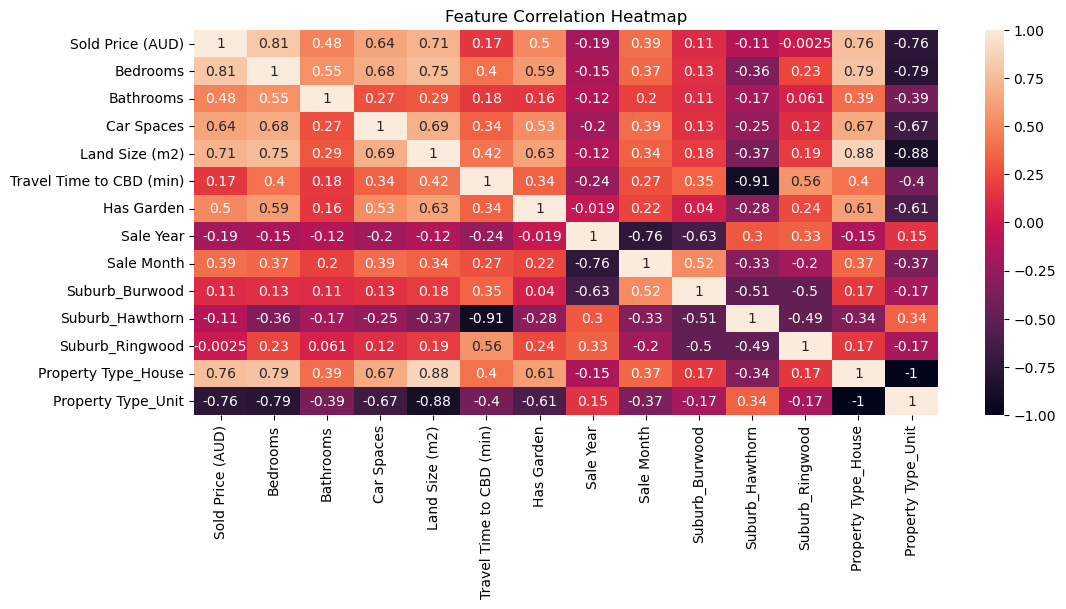

In [13]:
# Correlation heatmap
plt.figure(figsize=(12,5))
sns.heatmap(df.corr(),annot =True)
plt.title('Feature Correlation Heatmap')
plt.show()

### Observation:

The heatmap shows bedrooms (0.81) and land size (0.71) have the strongest correlation with sold price, while travel time barely matters.

## Model Development

In [14]:
x = df.drop(columns=['Sold Price (AUD)'])
y = df['Sold Price (AUD)']

In [15]:
# Define model
model = LinearRegression()

# K fold set up
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)

mae_scores = []
rmse_scores = []
r2_scores = []

for train_index, test_index in kf.split(x):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_scores.append(r2_score(y_test, y_pred))

print(f"MAE:  ${np.mean(mae_scores):,.0f}")
print(f"RMSE: ${np.mean(rmse_scores):,.0f}")
print(f"R2:   {np.mean(r2_scores):.3f}")

MAE:  $202,197
RMSE: $294,353
R2:   0.676


### Observation:
MAE - On average, the model's prediction is off by AUD202,197.  
RMSE - RMSE is noticeably higher than MAE, meaning some of the predictions are way off.  
R2 - The model gets about 68% of the pattern right.

## Model Evaluation

In [16]:
# Train on full dataset
lr_model = LinearRegression()
lr_model.fit(x,y)

# Get coefficients
importance_lr = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

print(importance_lr)

                     Feature    Coefficient
0                   Bedrooms  275305.939905
9            Suburb_Hawthorn  209093.419763
11       Property Type_House  145736.577219
3             Land Size (m2)   56894.516207
7                 Sale Month   45298.215479
1                  Bathrooms   43771.658779
2                 Car Spaces   31271.094021
4   Travel Time to CBD (min)    1168.371292
5                 Has Garden     220.310461
6                  Sale Year  -18627.735273
8             Suburb_Burwood  -78741.435880
10           Suburb_Ringwood -130351.983883
12        Property Type_Unit -145736.577219


### Observation:
The feature importance analysis showed that bedrooms, suburb location, and property type were the strongest predictors of price, while travel time to CBD and the presence of a garden had minimal impact.

## Conclusion
Ringwood is the most stable and predictable suburb, with consistent prices and few outliers, therefore it is a safer choice for buyers. Hawthorn has higher average prices but more volatility, driven by a few expensive properties, making it riskier but with higher potential value. Burwood falls in between, with a wider mix of affordable and high-end properties.
Across all three suburbs, bedrooms and property type were the strongest indicators of price, making them useful starting points when estimating a property's value.